In [14]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

ID_PREFIX = "HUPA00"
rename_mapping = {
    "Lows": "Low",
    "Mediums": "Medium",
    "Highs": "High",
    "Very Highs": "Very High"
}
new_category_order = ["Low", "Medium", "High", "Very High"]

directories = [d for d in os.listdir() if os.path.isdir(d) and d.startswith(ID_PREFIX)]

all_records = []

for directory in directories:
    file_path = os.path.join(directory, "rolling_window_glucose_prediction.csv")
    if not os.path.exists(file_path):
        continue

    df = pd.read_csv(file_path)
    df['Participant'] = directory
    df['Category'] = df['Category'].replace(rename_mapping)
    df['Correct'] = df['Prediction Status'].astype(int)

    for level in new_category_order:
        sub_df = df[df['Category'] == level]
        if sub_df.empty:
            continue

        y_true = sub_df['Actual Next Day Mean']
        y_pred = sub_df['Predicted Mean']
        y_std = sub_df['Predicted Standard Deviation'] if 'Predicted Standard Deviation' in sub_df.columns else np.full(len(sub_df), np.nan)
        lower = sub_df['Lower Bound']
        upper = sub_df['Upper Bound']
        correct = sub_df['Correct'].sum()
        total = len(sub_df)

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        accuracy = (correct / total) * 100
        mean_predicted = y_pred.mean()
        mean_predicted_std = y_std.mean()
        mean_actual = y_true.mean()

        outside_bounds = (y_true < lower) | (y_true > upper)
        bound_dev = np.where(y_true < lower, lower - y_true,
                             np.where(y_true > upper, y_true - upper, 0))
        mean_bound_dev = np.mean(bound_dev[outside_bounds]) if outside_bounds.sum() > 0 else 0.0

        all_records.append({
            "Participant": directory,
            "PA Level": level,
            "Accuracy (%)": round(accuracy, 2),
            "MAE": round(mae, 2),
            "RMSE": round(rmse, 2),
            "Mean Bound Deviation": round(mean_bound_dev, 2),
            "Avg Predicted Mean": round(mean_predicted, 2),
            "Predicted Standard Deviation": round(mean_predicted_std, 2),
            "Avg Actual Next Day Mean": round(mean_actual, 2),
            "Correct/Total Windows": f"{correct}/{total}"
        })

metrics_df = pd.DataFrame(all_records)
metrics_df['PA Level'] = pd.Categorical(metrics_df['PA Level'], categories=new_category_order, ordered=True)
metrics_df = metrics_df.sort_values(['PA Level', 'Participant'])

print("\n=== Full Prediction Metrics by Participant and PA Level ===\n")
print(metrics_df.to_string(index=False))

metrics_df.to_excel("full_prediction_metrics.xlsx", index=False)


=== Full Prediction Metrics by Participant and PA Level ===

Participant  PA Level  Accuracy (%)  MAE  RMSE  Mean Bound Deviation  Avg Predicted Mean  Predicted Standard Deviation  Avg Actual Next Day Mean Correct/Total Windows
   HUPA0001       Low        100.00 0.34  0.34                  0.00                0.79                          0.53                      1.13                   1/1
   HUPA0003       Low         50.00 0.26  0.32                  0.05                0.50                          0.38                      0.48                   2/4
   HUPA0007       Low        100.00 0.09  0.10                  0.00                0.76                          0.58                      0.67                   2/2
   HUPA0011       Low         66.67 0.33  0.41                  0.18                0.69                          0.55                      1.02                   2/3
   HUPA0014       Low        100.00 0.12  0.12                  0.00                0.45               

In [2]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

ID_PREFIX = "HUPA"
rename_mapping = {
    "Lows": "Low",
    "Mediums": "Medium",
    "Highs": "High",
    "Very Highs": "Very High"
}
new_category_order = ["Low", "Medium", "High", "Very High"]

directories = [d for d in os.listdir() if os.path.isdir(d) and d.startswith(ID_PREFIX)]

all_records = []

for directory in directories:
    file_path = os.path.join(directory, "rolling_window_glucose_prediction.csv")
    if not os.path.exists(file_path):
        continue

    df = pd.read_csv(file_path)
    df['Participant'] = directory
    df['Category'] = df['Category'].replace(rename_mapping)
    df['Correct'] = df['Prediction Status'].astype(int)

    for level in new_category_order:
        sub_df = df[df['Category'] == level]
        if sub_df.empty:
            continue

        y_true = sub_df['Actual Next Day Mean']
        y_pred = sub_df['Predicted Mean']
        lower = sub_df['Lower Bound']
        upper = sub_df['Upper Bound']
        correct = sub_df['Correct'].sum()
        total = len(sub_df)

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        accuracy = (correct / total) * 100

        outside_bounds = (y_true < lower) | (y_true > upper)
        bound_dev = np.where(y_true < lower, lower - y_true,
                             np.where(y_true > upper, y_true - upper, 0))
        mean_bound_dev = np.mean(bound_dev[outside_bounds]) if outside_bounds.sum() > 0 else 0.0

        all_records.append({
            "Participant": directory,
            "PA Level": level,
            "Accuracy (%)": round(accuracy, 2),
            "MAE": round(mae, 2),
            "RMSE": round(rmse, 2),
            "Mean Bound Deviation": round(mean_bound_dev, 2),
            "Correct/Total Windows": f"{correct}/{total}"
        })

metrics_df = pd.DataFrame(all_records)
metrics_df['PA Level'] = pd.Categorical(metrics_df['PA Level'], categories=new_category_order, ordered=True)
metrics_df = metrics_df.sort_values(['PA Level', 'Participant'])

print("\n=== Full Prediction Metrics by Participant and PA Level ===\n")
print(metrics_df.to_string(index=False))



=== Full Prediction Metrics by Participant and PA Level ===

Participant  PA Level  Accuracy (%)  MAE  RMSE  Mean Bound Deviation Correct/Total Windows
   HUPA0001       Low        100.00 0.34  0.34                  0.00                   1/1
   HUPA0003       Low         50.00 0.26  0.32                  0.05                   2/4
   HUPA0007       Low        100.00 0.09  0.10                  0.00                   2/2
   HUPA0011       Low         66.67 0.33  0.41                  0.18                   2/3
   HUPA0014       Low        100.00 0.12  0.12                  0.00                   1/1
   HUPA0018       Low        100.00 0.17  0.20                  0.00                   4/4
   HUPA0025       Low        100.00 0.25  0.27                  0.00                   4/4
   HUPA0026       Low         83.61 0.34  0.49                  0.39               102/122
   HUPA0027       Low         80.51 0.35  0.47                  0.34               314/390
   HUPA0028       Low       

In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

summary_records = []

for level in new_category_order:
    level_df = metrics_df[metrics_df['PA Level'] == level]
    if level_df.empty:
        continue

    correct_total_split = level_df['Correct/Total Windows'].str.split('/', expand=True).astype(int)
    total_correct = correct_total_split[0].sum()
    total_all = correct_total_split[1].sum()
    accuracy = (total_correct / total_all) * 100

    mae = np.average(level_df['MAE'], weights=correct_total_split[1])
    rmse = np.average(level_df['RMSE'], weights=correct_total_split[1])
    mean_bound_dev = np.average(level_df['Mean Bound Deviation'], weights=correct_total_split[1])

    summary_records.append({
        "PA Level": level,
        "Accuracy (%)": round(accuracy, 2),
        "Correct Windows": total_correct,
        "Total Windows": total_all,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "Mean Bound Deviation": round(mean_bound_dev, 2)
    })

summary_df = pd.DataFrame(summary_records)
print("\n=== Generalised Performance Summary by PA Level ===\n")
print(summary_df.to_string(index=False))



=== Generalised Performance Summary by PA Level ===

 PA Level  Accuracy (%)  Correct Windows  Total Windows  MAE  RMSE  Mean Bound Deviation
      Low         81.55              473            580 0.35  0.48                  0.36
   Medium         81.72              474            580 0.32  0.42                  0.26
     High         83.33              480            576 0.36  0.49                  0.39
Very High         81.64              418            512 0.39  0.54                  0.43


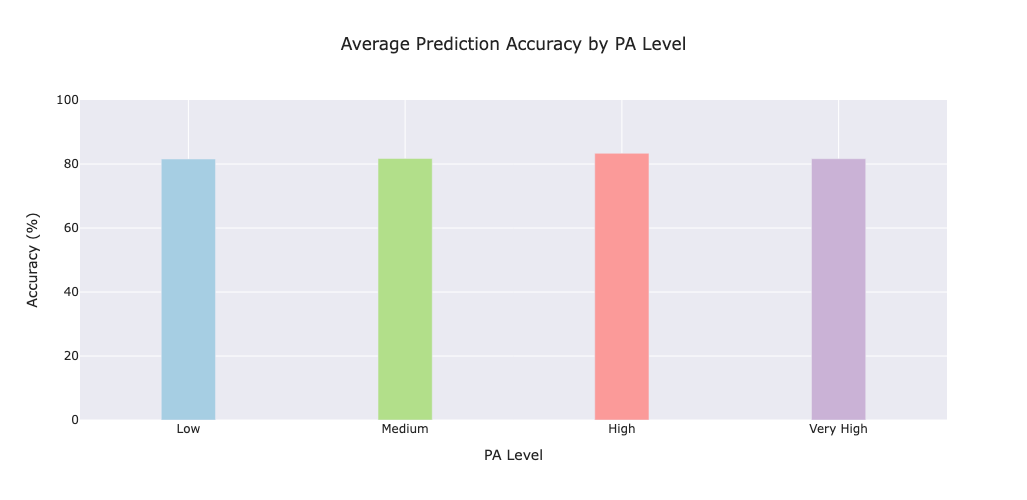

In [4]:
import os
import pandas as pd
import plotly.graph_objects as go

custom_colors = ['#a6cee3', '#b2df8a', '#fb9a99', '#cab2d6']  # blue, green, red, violet pastel tones

ID_PREFIX = "HUPA"
rename_mapping = {
    "Lows": "Low",
    "Mediums": "Medium",
    "Highs": "High",
    "Very Highs": "Very High"
}
new_category_order = ["Low", "Medium", "High", "Very High"]

directories = [d for d in os.listdir() if os.path.isdir(d) and d.startswith(ID_PREFIX)]
combined_df = []

for directory in directories:
    file_path = os.path.join(directory, "rolling_window_glucose_prediction.csv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df['Participant'] = directory
        df['Category'] = df['Category'].replace(rename_mapping)
        combined_df.append(df)

df_all = pd.concat(combined_df, ignore_index=True)
df_all['Category'] = pd.Categorical(df_all['Category'], categories=new_category_order, ordered=True)
df_all['Correct'] = df_all['Prediction Status'].astype(int)

accuracy_df = df_all.groupby('Category', observed=False)['Correct'].mean().reset_index()
accuracy_df['Accuracy (%)'] = 100 * accuracy_df['Correct']

fig = go.Figure(go.Bar(
    x=accuracy_df['Category'],
    y=accuracy_df['Accuracy (%)'],
    marker_color=custom_colors,
    width=0.25,  # THINNER bars
    text=None,
    hovertemplate='<b>%{x}</b><br>Accuracy: %{y:.2f}%<extra></extra>'
))

fig.update_layout(
    title='Average Prediction Accuracy by PA Level',
    xaxis_title='PA Level',
    yaxis_title='Accuracy (%)',
    yaxis_range=[0, 100],
    bargap=0.6,  # More space between bars
    template='seaborn',
    showlegend=False,
    height=500,
    width=800,
    font=dict(size=12)
)

fig.show()
#fig.write_image("glucose_prediction_scatter.png", width=800, height=500, scale=1)

In [5]:
import plotly.express as px

fig_mae = px.box(
    metrics_df,
    x='PA Level',
    y='MAE',
    color='PA Level',
    title='Distribution of MAE Across PA Levels',
    points='all',
    template='seaborn'
)
fig_mae.update_layout(
    showlegend=False,
    width=800,
    height=500
)
fig.write_image("mae.png", width=800, height=500, scale=1)

In [6]:
fig_rmse = px.box(
    metrics_df,
    x='PA Level',
    y='RMSE',
    color='PA Level',
    title='Distribution of RMSE Across PA Levels',
    points='all',
    template='seaborn'
)
fig_rmse.update_layout(
    showlegend=False,
    width=800,
    height=500
)
fig_rmse.show()


In [7]:
metrics_df[['Correct', 'Total']] = metrics_df['Correct/Total Windows'].str.split('/', expand=True).astype(int)
metrics_df['Incorrect'] = metrics_df['Total'] - metrics_df['Correct']

violin_df = metrics_df[metrics_df['Incorrect'] > 0].copy()

fig_violin = px.violin(
    violin_df,
    x='PA Level',
    y='Mean Bound Deviation',
    color='PA Level',
    box=True,
    points='all',
    title='Mean Bound Deviation (Incorrect Predictions Only)',
    template='seaborn'
)
fig_violin.update_layout(
    showlegend=False,
    width=800,
    height=500
)
fig_violin.show()


In [8]:
import os
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

ID_PREFIX = "HUPA"
rename_mapping = {
    "Lows": "Low",
    "Mediums": "Medium",
    "Highs": "High",
    "Very Highs": "Very High"
}
new_category_order = ["Low", "Medium", "High", "Very High"]

directories = [d for d in os.listdir() if os.path.isdir(d) and d.startswith(ID_PREFIX)]

combined_df = []
for directory in directories:
    file_path = os.path.join(directory, "rolling_window_glucose_prediction.csv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df['Participant'] = directory
        df['Category'] = df['Category'].replace(rename_mapping)
        combined_df.append(df)

combined_df = pd.concat(combined_df, ignore_index=True)
combined_df['Category'] = pd.Categorical(combined_df['Category'], categories=new_category_order, ordered=True)

mean_df = combined_df.groupby(['Participant', 'Category'], as_index=False, observed=False).agg({
    'Predicted Mean': 'mean',
    'Actual Next Day Mean': 'mean',
    'Predicted Standard Deviation': 'mean'
}).rename(columns={'Predicted Standard Deviation': 'Pred_SD'})

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=new_category_order,
    shared_xaxes=False, shared_yaxes=False
)

subplot_map = {
    "Low": (1, 1),
    "Medium": (1, 2),
    "High": (2, 1),
    "Very High": (2, 2)
}

for level in new_category_order:
    sub_df = mean_df[mean_df['Category'] == level]
    row, col = subplot_map[level]

    # Predicted with error bars (diamond)
    fig.add_trace(go.Scatter(
        x=sub_df['Actual Next Day Mean'],
        y=sub_df['Predicted Mean'],
        mode='markers',
        marker=dict(symbol='diamond', size=8, color='firebrick'),
        error_y=dict(type='data', array=sub_df['Pred_SD'], visible=True),
        name='Predicted',
        showlegend=(row == 1 and col == 1)
    ), row=row, col=col)

    fig.add_trace(go.Scatter(
        x=sub_df['Actual Next Day Mean'],
        y=sub_df['Actual Next Day Mean'],
        mode='markers',
        marker=dict(symbol='cross', size=7, color='royalblue'),
        name='Actual',
        showlegend=(row == 1 and col == 1)
    ), row=row, col=col)

    fig.add_trace(go.Scatter(
        x=sub_df['Actual Next Day Mean'],
        y=sub_df['Actual Next Day Mean'],
        mode='lines',
        line=dict(color='gray', dash='dash'),
        showlegend=False
    ), row=row, col=col)

    fig.update_xaxes(title_text="Actual Mean", row=row, col=col)
    fig.update_yaxes(title_text="Predicted Mean", row=row, col=col)

fig.update_layout(
    height=850,
    width=1000,
    template='seaborn',
    title="Predicted vs Actual Glucose Change per PA Level (with Error Bars)",
    legend_title="Data Type"
)

fig.show()


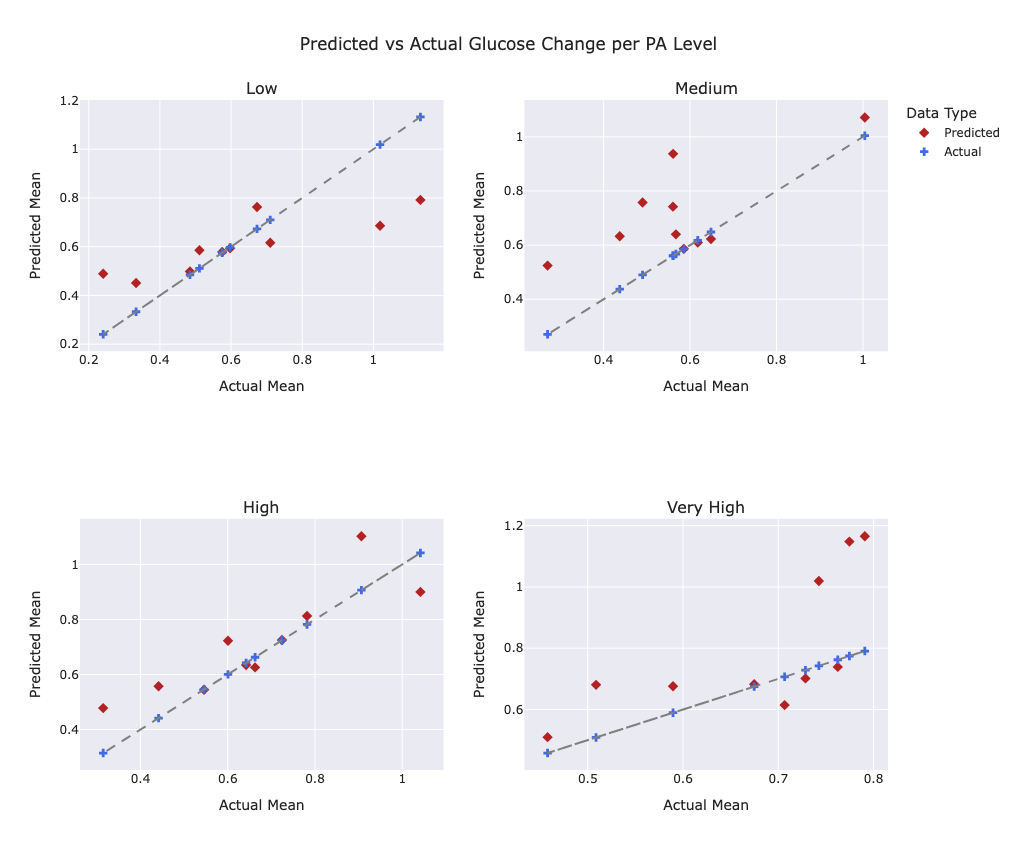

In [9]:
import os
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

ID_PREFIX = "HUPA"
rename_mapping = {
    "Lows": "Low",
    "Mediums": "Medium",
    "Highs": "High",
    "Very Highs": "Very High"
}
new_category_order = ["Low", "Medium", "High", "Very High"]

directories = [d for d in os.listdir() if os.path.isdir(d) and d.startswith(ID_PREFIX)]

combined_df = []
for directory in directories:
    file_path = os.path.join(directory, "rolling_window_glucose_prediction.csv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df['Participant'] = directory
        df['Category'] = df['Category'].replace(rename_mapping)
        combined_df.append(df)

combined_df = pd.concat(combined_df, ignore_index=True)
combined_df['Category'] = pd.Categorical(combined_df['Category'], categories=new_category_order, ordered=True)

mean_df = combined_df.groupby(['Participant', 'Category'], as_index=False, observed=False).agg({
    'Predicted Mean': 'mean',
    'Actual Next Day Mean': 'mean'
})

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=new_category_order,
    shared_xaxes=False, shared_yaxes=False
)

subplot_map = {
    "Low": (1, 1),
    "Medium": (1, 2),
    "High": (2, 1),
    "Very High": (2, 2)
}

for level in new_category_order:
    sub_df = mean_df[mean_df['Category'] == level]
    row, col = subplot_map[level]

    fig.add_trace(go.Scatter(
        x=sub_df['Actual Next Day Mean'],
        y=sub_df['Predicted Mean'],
        mode='markers',
        marker=dict(symbol='diamond', size=8, color='firebrick'),
        name='Predicted',
        showlegend=(row == 1 and col == 1)
    ), row=row, col=col)

    fig.add_trace(go.Scatter(
        x=sub_df['Actual Next Day Mean'],
        y=sub_df['Actual Next Day Mean'],
        mode='markers',
        marker=dict(symbol='cross', size=7, color='royalblue'),
        name='Actual',
        showlegend=(row == 1 and col == 1)
    ), row=row, col=col)

    fig.add_trace(go.Scatter(
        x=sub_df['Actual Next Day Mean'],
        y=sub_df['Actual Next Day Mean'],
        mode='lines',
        line=dict(color='gray', dash='dash'),
        showlegend=False
    ), row=row, col=col)

    fig.update_xaxes(title_text="Actual Mean", row=row, col=col)
    fig.update_yaxes(title_text="Predicted Mean", row=row, col=col)

fig.update_layout(
    height=850,
    width=1000,
    template='seaborn',
    title="Predicted vs Actual Glucose Change per PA Level",
    legend_title="Data Type"
)

fig.show()


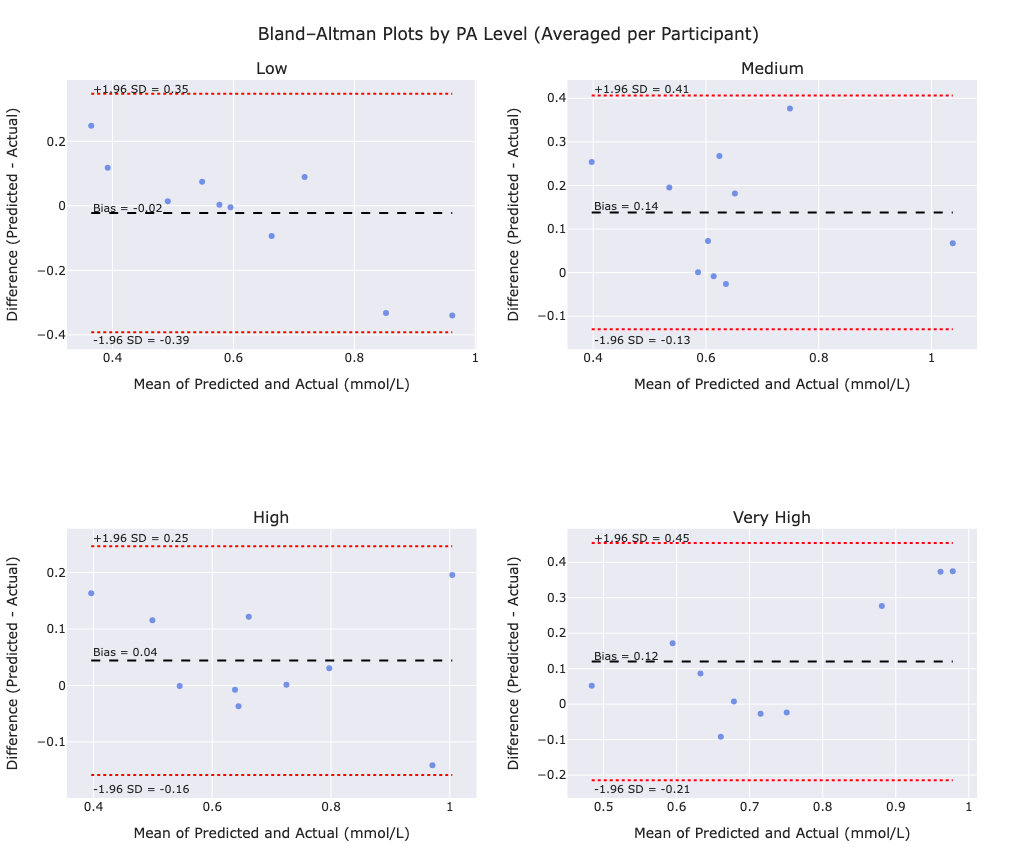

In [10]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df_all = df_all.dropna(subset=["Predicted Mean", "Actual Next Day Mean"])
df_all['Mean'] = (df_all['Predicted Mean'] + df_all['Actual Next Day Mean']) / 2
df_all['Difference'] = df_all['Predicted Mean'] - df_all['Actual Next Day Mean']

grouped_df = df_all.groupby(['Participant', 'Category'], observed=False).agg({
    'Mean': 'mean',
    'Difference': 'mean'
}).reset_index()

pa_levels = ['Low', 'Medium', 'High', 'Very High']
fig = make_subplots(rows=2, cols=2, subplot_titles=pa_levels)
pos_map = {0: (1, 1), 1: (1, 2), 2: (2, 1), 3: (2, 2)}

for i, level in enumerate(pa_levels):
    sub = grouped_df[grouped_df['Category'] == level]
    row, col = pos_map[i]
    mean = sub['Mean']
    diff = sub['Difference']
    bias = diff.mean()
    std = diff.std()
    loa_upper = bias + 1.96 * std
    loa_lower = bias - 1.96 * std

    fig.add_trace(go.Scatter(
        x=mean, y=diff, mode='markers',
        marker=dict(color='royalblue', size=6, opacity=0.7),
        showlegend=False
    ), row=row, col=col)

    lines = [(bias, "Bias", 'dash', 0.015),
             (loa_upper, "+1.96 SD", 'dot', 0.015),
             (loa_lower, "-1.96 SD", 'dot', -0.025)]

    for y_val, label, style, offset in lines:
        fig.add_trace(go.Scatter(
            x=[mean.min(), mean.max()],
            y=[y_val, y_val],
            mode='lines',
            line=dict(color='red' if 'SD' in label else 'black', dash=style),
            showlegend=False
        ), row=row, col=col)

        fig.add_annotation(
            x=mean.min(),
            y=y_val + offset,
            text=f"{label} = {y_val:.2f}",
            showarrow=False,
            font=dict(size=11),
            xanchor='left',
            row=row, col=col
        )

    fig.update_xaxes(title_text="Mean of Predicted and Actual (mmol/L)", row=row, col=col)
    fig.update_yaxes(title_text="Difference (Predicted - Actual)", row=row, col=col)

fig.update_layout(
    height=850,
    width=1000,
    template="seaborn",
    title="Bland–Altman Plots by PA Level (Averaged per Participant)",
    margin=dict(t=80, l=40, r=40, b=40)
)

fig.show()
